<a href="https://colab.research.google.com/github/dipalisalunke3199/Google-Play-Store-Apps---Exploratory-Data-Analysis-EDA-/blob/main/app_insights_googleplaystore_EDA_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**App Insight Analysis EDA Project**

**1.Import Libraries**

In [1]:
import pandas as pd
import numpy as np

In [2]:
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder

**2.Load Dataset**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving googleplaystore.csv to googleplaystore.csv


In [4]:
import pandas as pd

df = pd.read_csv("googleplaystore.csv")

**3. Understand Dataset**

In [5]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [6]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [7]:
df.shape

(10841, 13)

In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [9]:
df.nunique()

,0
App,9660
Category,34
Rating,40
Reviews,6002
Size,462
Installs,22
Type,3
Price,93
Content Rating,6
Genres,120


**4. Data Cleaning & Preprocessing**

In [10]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [11]:
df['Rating'].fillna(
    df['Rating'].median(),
    inplace=True
)

/tmp/ipykernel_9323/110642288.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(


In [12]:
df['Type'].fillna(
    df['Type'].mode()[0],
    inplace=True
)

/tmp/ipykernel_9323/3038675612.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Type'].fillna(


In [13]:
df['Content Rating'].fillna(
    df['Content Rating'].mode()[0],
    inplace=True
)

/tmp/ipykernel_9323/1229444880.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Content Rating'].fillna(


In [14]:
df['Current Ver'].fillna(
    "Unknown",
    inplace=True
)

/tmp/ipykernel_9323/4131655403.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Current Ver'].fillna(


In [15]:
df['Android Ver'].fillna(
    df['Android Ver'].mode()[0],
    inplace=True
)

/tmp/ipykernel_9323/1436136364.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Android Ver'].fillna(


In [16]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.shape

(10358, 13)

In [19]:
df['Category'].value_counts()

,count
Category,
FAMILY,1943
GAME,1121
TOOLS,843
BUSINESS,427
MEDICAL,408
PRODUCTIVITY,407
PERSONALIZATION,388
LIFESTYLE,373
COMMUNICATION,366


In [20]:
df[df['Category'] == '1.9']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,Everyone,"February 11, 2018",1.0.19,4.0 and up,4.1 and up


In [21]:
df = df[df['Category'] != '1.9']

In [22]:
df['Genres'].value_counts()

,count
Genres,
Tools,842
Entertainment,588
Education,527
Business,427
Medical,408
...,...
Role Playing;Brain Games,1
Strategy;Education,1
Racing;Pretend Play,1


In [23]:
df['Type'].value_counts()

,count
Type,
Free,9592
Paid,765


In [24]:
df['Content Rating'].value_counts()

,count
Content Rating,
Everyone,8382
Teen,1146
Mature 17+,447
Everyone 10+,377
Adults only 18+,3
Unrated,2


In [25]:
df['Reviews'] = pd.to_numeric(df['Reviews'])

In [26]:
df['Installs'] = df['Installs'].str.replace(',', '')
df['Installs'] = df['Installs'].str.replace('+', '')
df['Installs'] = df['Installs'].astype(int)

In [27]:
df['Installs'].dtype

dtype('int64')

In [28]:
df['Price'] = df['Price'].str.replace('$', '')
df['Price'] = df['Price'].astype(float)

In [29]:
import numpy as np

def convert_size(size):

    if 'M' in str(size):
        return float(size.replace('M', ''))

    elif 'k' in str(size):
        return float(size.replace('k', '')) / 1024

    else:
        return np.nan

In [30]:
df['Size'] = df['Size'].apply(convert_size)

In [31]:
df['Size'].fillna(
    df['Size'].median(),
    inplace=True
)

/tmp/ipykernel_9323/2902751724.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Size'].fillna(


In [32]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'])

In [33]:
df['Last Updated'].dtype

dtype('<M8[ns]')

In [34]:
df['Update Year'] = df['Last Updated'].dt.year
df['Update Month'] = df['Last Updated'].dt.month

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10357 non-null  object        
 1   Category        10357 non-null  object        
 2   Rating          10357 non-null  float64       
 3   Reviews         10357 non-null  int64         
 4   Size            10357 non-null  float64       
 5   Installs        10357 non-null  int64         
 6   Type            10357 non-null  object        
 7   Price           10357 non-null  float64       
 8   Content Rating  10357 non-null  object        
 9   Genres          10357 non-null  object        
 10  Last Updated    10357 non-null  datetime64[ns]
 11  Current Ver     10357 non-null  object        
 12  Android Ver     10357 non-null  object        
 13  Update Year     10357 non-null  int32         
 14  Update Month    10357 non-null  int32         
dtypes: date

In [ ]:
from google.colab import files

df.to_csv("google_playstore_cleaned.csv", index=False)
files.download("google_playstore_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**5. Exploratory Data Analysis (EDA)**

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

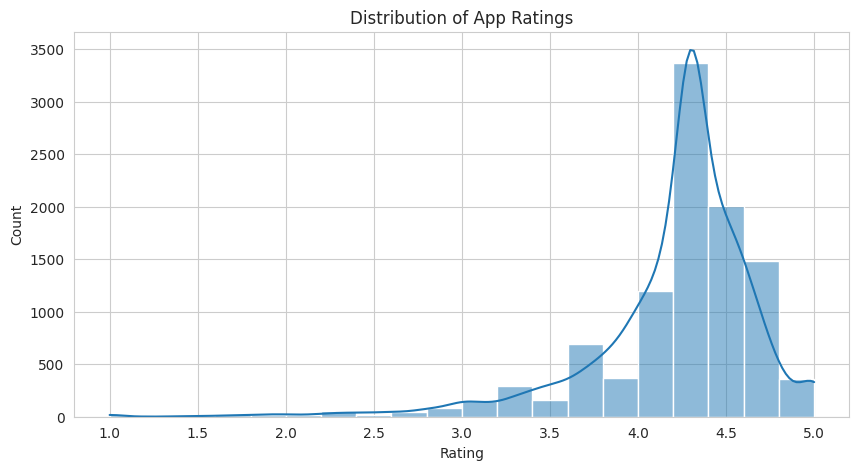

In [37]:
sns.histplot(df['Rating'], bins=20, kde=True)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

Insight: Most apps have ratings between 4.0–4.5, indicating generally positive user satisfaction on the Play Store.

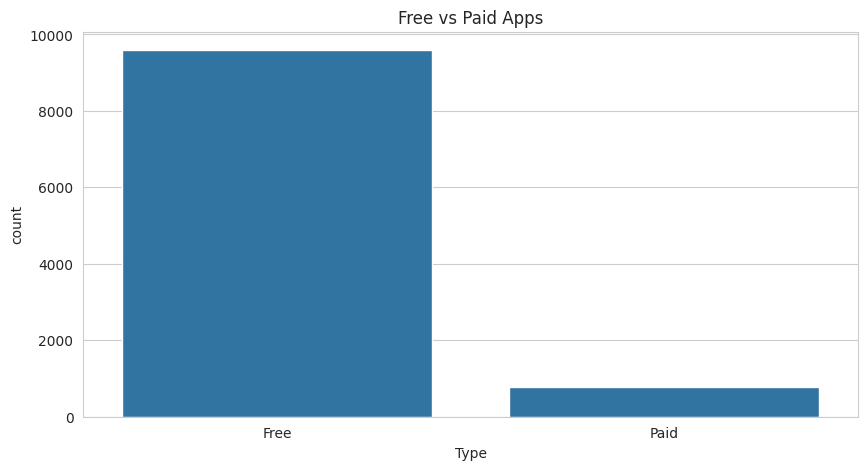

In [38]:
sns.countplot(x='Type', data=df)

plt.title("Free vs Paid Apps")
plt.show()

Insight: Free apps significantly outnumber paid apps, showing a strong preference for the freemium business model.

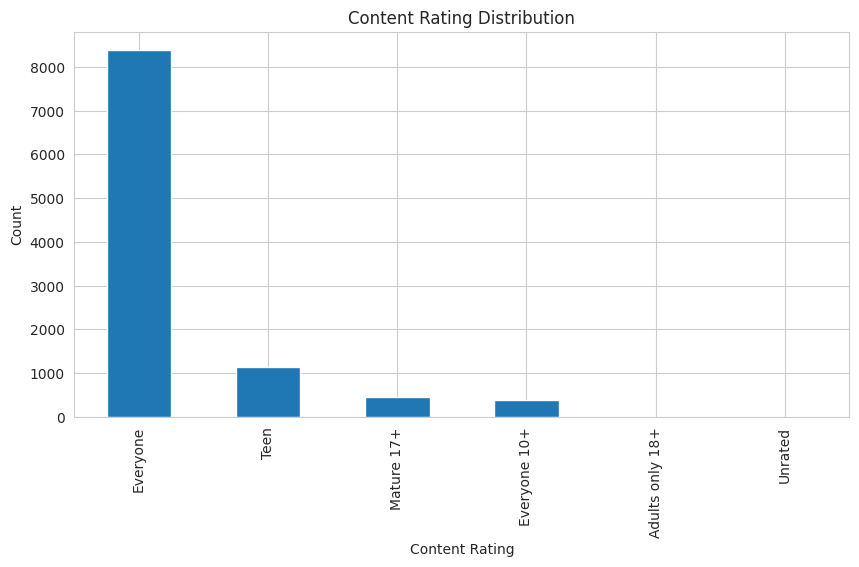

In [39]:
df['Content Rating'].value_counts().plot(
    kind='bar'
)

plt.title("Content Rating Distribution")
plt.ylabel("Count")

plt.show()

Insight: The majority of apps are rated “Everyone,” suggesting broader audience targeting by developers.

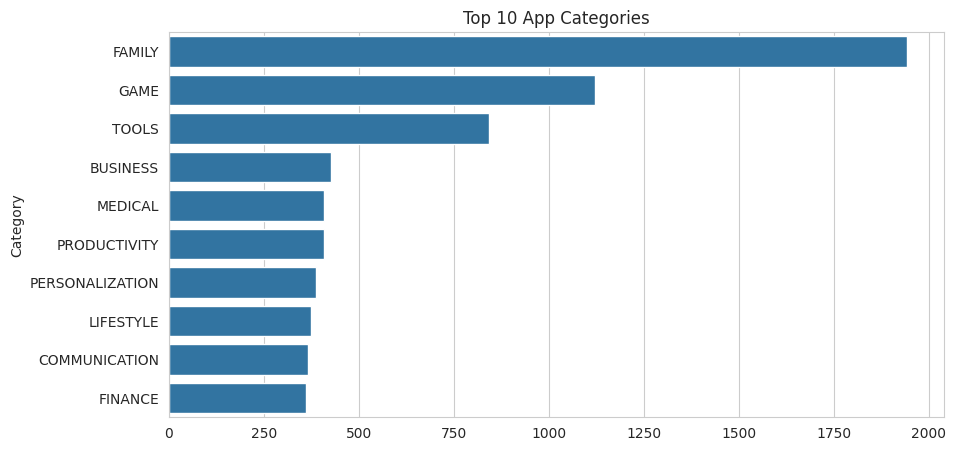

In [40]:
top_categories = df['Category'].value_counts().head(10)

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 10 App Categories")

plt.show()

Insight: Family, Games, and Tools dominate the Play Store, indicating high app availability in these categories.

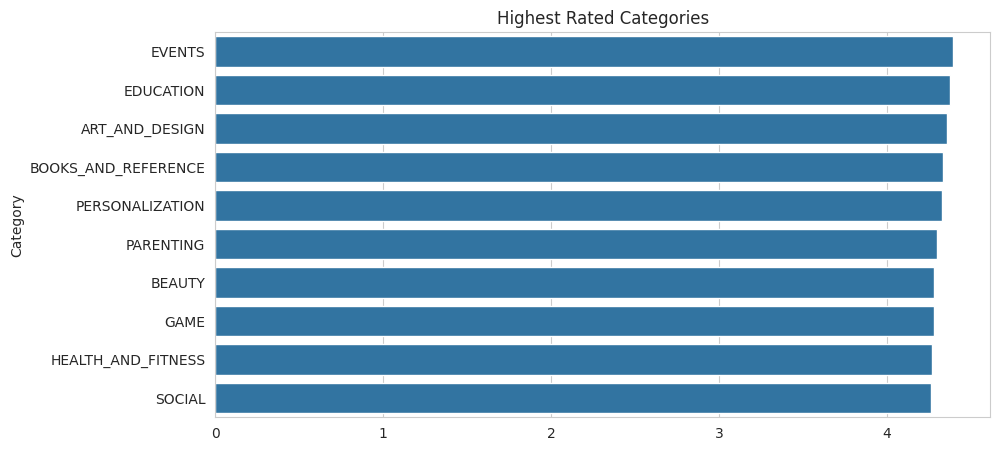

In [41]:
highest_rating = df.groupby(
    'Category'
)['Rating'].mean().sort_values(
    ascending=False
).head(10)

sns.barplot(
    x=highest_rating.values,
    y=highest_rating.index
)

plt.title("Highest Rated Categories")

plt.show()

Insight: Certain niche categories maintain higher average ratings, reflecting better user satisfaction and app quality.

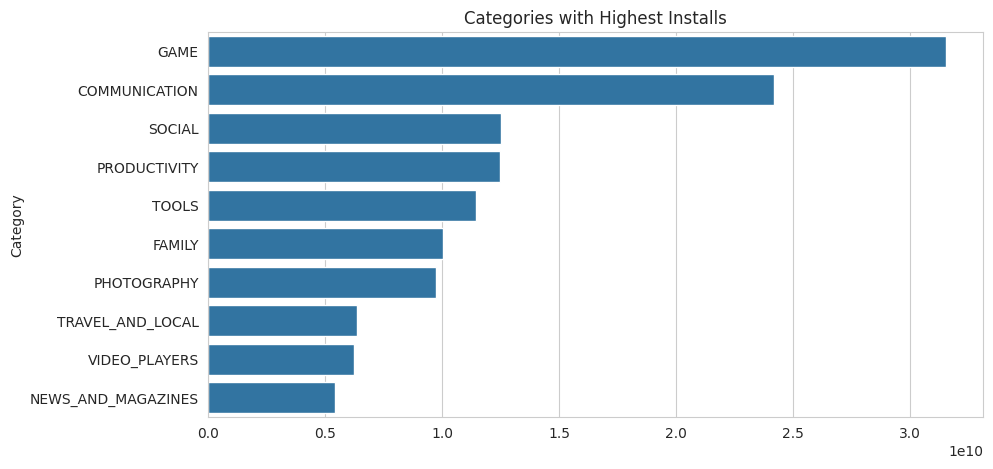

In [42]:
top_installs = df.groupby(
    'Category'
)['Installs'].sum().sort_values(
    ascending=False
).head(10)

sns.barplot(
    x=top_installs.values,
    y=top_installs.index
)

plt.title("Categories with Highest Installs")

plt.show()

Insight: Categories like Communication and Tools receive the highest installs due to their daily utility and wider audience reach.

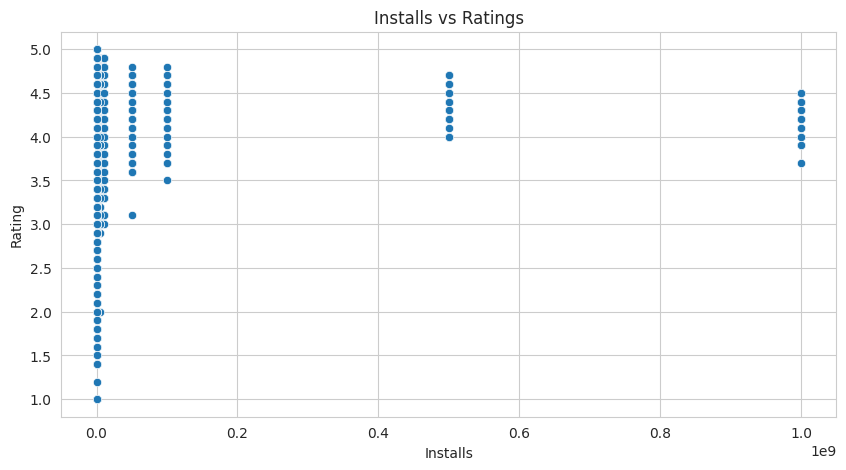

In [43]:
sns.scatterplot(
    x='Installs',
    y='Rating',
    data=df
)

plt.title("Installs vs Ratings")

plt.show()

Insight: Apps with higher installs generally maintain strong ratings, suggesting popularity often aligns with user satisfaction.

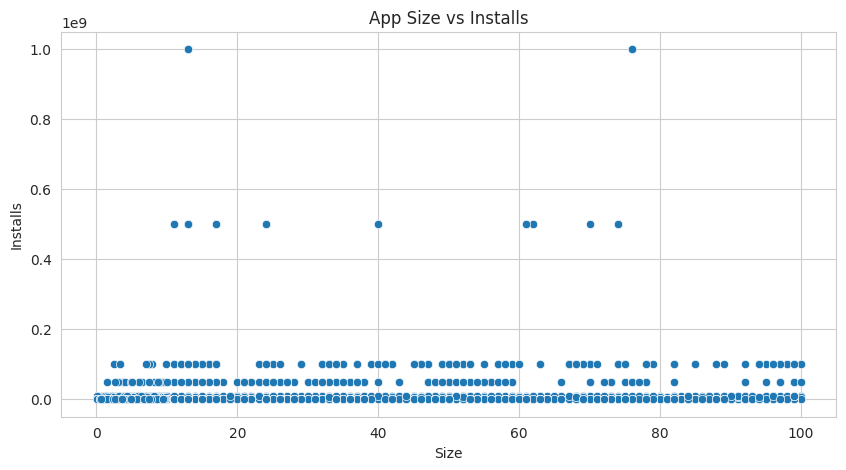

In [44]:
sns.scatterplot(
    x='Size',
    y='Installs',
    data=df
)

plt.title("App Size vs Installs")

plt.show()

Insight: No strong relationship exists between app size and installs, indicating users prioritize functionality over size.

In [45]:
numeric_cols = [
    'Rating',
    'Reviews',
    'Size',
    'Installs',
    'Price'
]

corr = df[numeric_cols].corr()

In [46]:
paid_apps = df[df['Type'] == 'Paid']

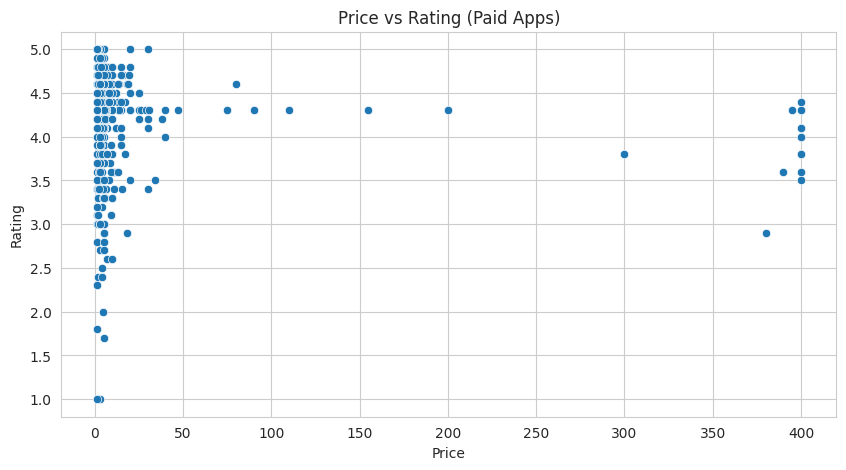

In [47]:
sns.scatterplot(
    x='Price',
    y='Rating',
    data=paid_apps
)

plt.title("Price vs Rating (Paid Apps)")

plt.show()

Insight: Paid app pricing shows little impact on ratings, meaning app quality matters more than cost.

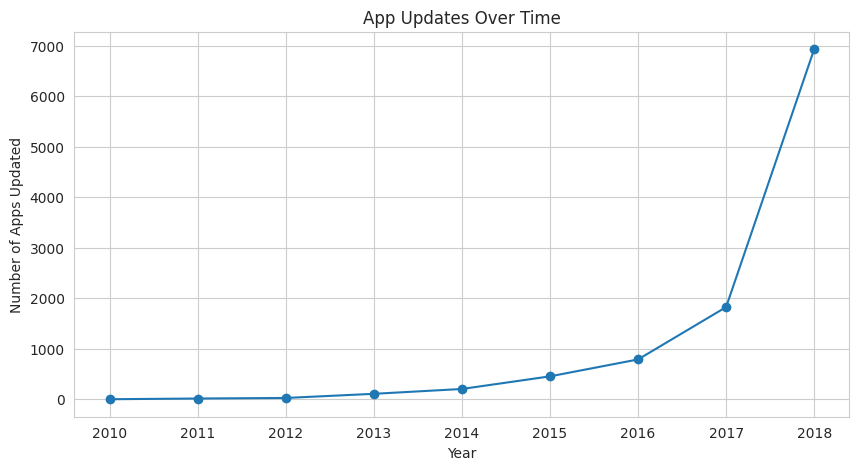

In [48]:
df['Update Year'].value_counts().sort_index().plot(
    kind='line',
    marker='o'
)

plt.title("App Updates Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Apps Updated")

plt.show()

Insight: App updates increased over the years, reflecting continuous maintenance and feature improvements by developers.

In [49]:
top_apps = df.sort_values(
    by='Installs',
    ascending=False
)[['App','Category','Installs']].head(10)

top_apps

,App,Category,Installs
3454,Google Drive,PRODUCTIVITY,1000000000
865,Google Play Games,ENTERTAINMENT,1000000000
3523,Google Drive,PRODUCTIVITY,1000000000
2544,Facebook,SOCIAL,1000000000
2545,Instagram,SOCIAL,1000000000
464,Hangouts,COMMUNICATION,1000000000
3223,Maps - Navigate & Explore,TRAVEL_AND_LOCAL,1000000000
3816,Google News,NEWS_AND_MAGAZINES,1000000000
4170,Google Drive,PRODUCTIVITY,1000000000
3896,Subway Surfers,GAME,1000000000


Insights: Top-installed apps are dominated by social media, productivity, communication, and Google ecosystem apps, reflecting strong demand for daily-use applications.

In [50]:
top_reviewed = df.sort_values(
    by='Reviews',
    ascending=False
)[['App','Reviews','Rating']].head(10)

top_reviewed

,App,Reviews,Rating
2544,Facebook,78158306,4.1
3943,Facebook,78128208,4.1
336,WhatsApp Messenger,69119316,4.4
3904,WhatsApp Messenger,69109672,4.4
2604,Instagram,66577446,4.5
2545,Instagram,66577313,4.5
3909,Instagram,66509917,4.5
382,Messenger – Text and Video Chat for Free,56646578,4.0
335,Messenger – Text and Video Chat for Free,56642847,4.0
1879,Clash of Clans,44893888,4.6


Insight: Social media and messaging apps dominate user reviews, showing exceptionally high engagement and active global user bases.

In [51]:
import numpy as np

df['Success_Score'] = (
    df['Rating'] * 0.4 +
    np.log1p(df['Installs']) * 0.3 +
    np.log1p(df['Reviews']) * 0.3
)

In [52]:
df.sort_values(
    by='Success_Score',
    ascending=False
)[['App','Success_Score']].head(10)

,App,Success_Score
2604,Instagram,13.421143
2545,Instagram,13.421142
3909,Instagram,13.420838
336,WhatsApp Messenger,13.392383
3904,WhatsApp Messenger,13.392341
2544,Facebook,13.309254
3943,Facebook,13.309138
382,Messenger – Text and Video Chat for Free,13.172682
335,Messenger – Text and Video Chat for Free,13.172663
4005,Clean Master- Space Cleaner & Antivirus,13.161466


Insight: Social and communication apps dominate the Success Score ranking, indicating that high installs, reviews, and ratings strongly contribute to app success.